In [2]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
from erebus.wrapped_fits import WrappedFits
from erebus.photometry_data import PhotometryData


import matplotlib.colors as mcolors

import numpy as np
import glob
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration

from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture

plt.rcParams.update({
    'font.size': 14
})

In [7]:
visit_fits_files = glob.glob("./FNPCA individual fits with fixed*/*visit*.h5")
visit_fits = [IndividualFitResults.load(v) for v in visit_fits_files]

photo1 = PhotometryData.load("./PCA photometry/GJ3929b_photometry_0.h5")
photo2 = PhotometryData.load("./PCA photometry/GJ3929b_photometry_1.h5")
photo3 = PhotometryData.load("./PCA photometry/GJ3929b_photometry_2.h5")
photo4 = PhotometryData.load("./PCA photometry/Full Visit 4 Photometry.h5")

photometry = [photo1, photo2, photo3, photo4]

2026-05-26 15:39:16,430 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



In [8]:
visit_fits[0].__dict__.keys()

dict_keys(['BIC', 'config', 'config_hash', 'final_log_likelihood', 'order', 'planet', 'planet_name', 'predicted_t_sec', 'results', 'start_time', 'visit_name', 'eigenvalues', 'eigenvectors', 'flux_model', 'frames', 'pca_variance_ratios', 'raw_flux', 'systematic_factor', 'time'])

In [9]:
photometry[0].__dict__.keys()

dict_keys(['_cache_file', 'annulus_end', 'annulus_start', 'fits_file_location', 'radius', 'source_folder', 'visit_name', 'normalized_frames', 'raw_flux', 'time'])

In [40]:
def plot(t, f, frame, ev, evec, filename):
	t = t * 24
	t = t - np.min(t)
	
	fig, axs = plt.subplots(6, 2, figsize = (5, 6), 
							gridspec_kw = {'width_ratios': [4, 1], 'hspace': 0, 'wspace': 0},
							sharex = 'col')
	
	for ax in axs[:, 1]:
		ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
	
	axs[0, 0].plot(t, f, color='black')
	axs[0, 1].imshow(frame)

	bin_size = len(t) // 40
	bin_t, _ = bin_data(t, bin_size)
	
	for i in range(5):
		eigenvalue_ax = axs[i+1, 0]
		evec_ax = axs[i+1, 1]

		bin_ev, _ = bin_data(ev[i], bin_size)
		
		eigenvalue_ax.plot(t, ev[i])
		eigenvalue_ax.tick_params(left=False, labelleft=False)
		eigenvalue_ax.set_ylabel(f"PC {i+1}")

		eigenvalue_ax.plot(bin_t, bin_ev, marker='.', linestyle='')
		
	
		vmax = np.max(np.abs(evec))
		norm = mcolors.SymLogNorm(linthresh = 0.1, vmin=-vmax, vmax=vmax)
	
		im = evec_ax.imshow(evec[i], cmap='RdBu_r', norm=norm)
	
	cbar_ax = fig.add_axes([
	    axs[1, 1].get_position().x1,
	    axs[5, 1].get_position().y0,
	    0.02,
	    axs[1, 1].get_position().y1 - axs[5, 1].get_position().y0
	])
	
	cbar = fig.colorbar(im, cax=cbar_ax, ticks=[-1, 0, 1])
	cbar.set_ticklabels(['-1', '0', '1'])
	
	axs[0, 0].set_ylabel("Raw flux\n(ppm)")
	axs[-1, 0].set_xlabel("Time from start (hours)")
	plt.savefig("figures/" + filename, bbox_inches='tight')
	plt.show()

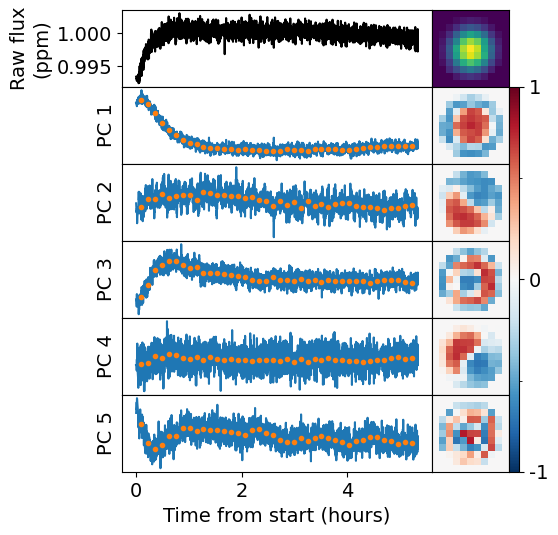

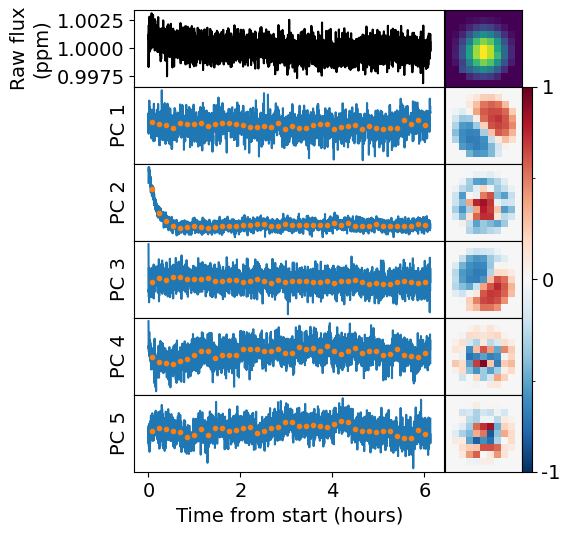

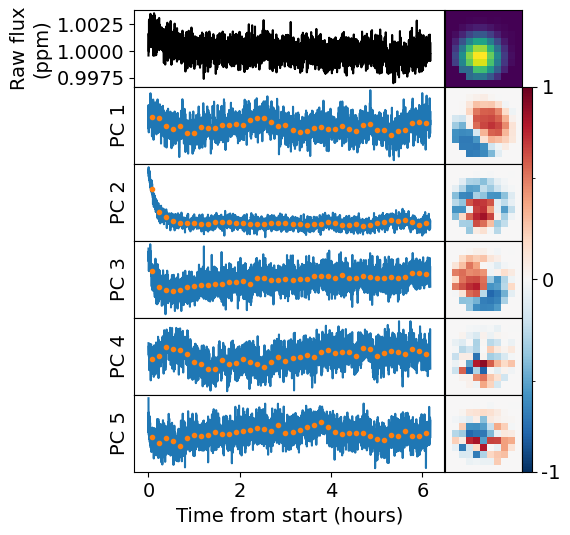

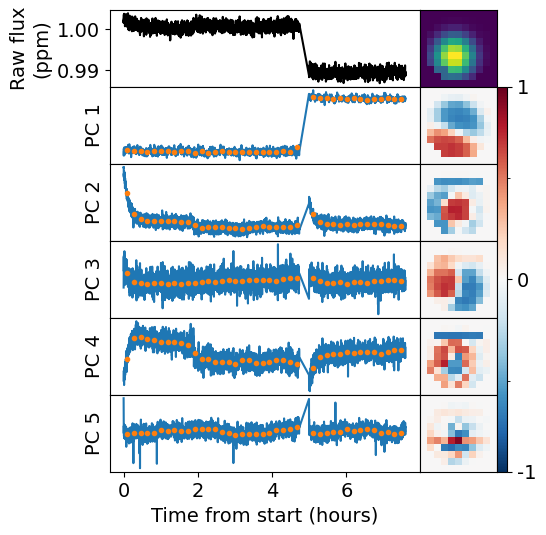

In [41]:
for i, photo in enumerate(photometry):
	f = photo.raw_flux
	t = photo.time
	frame = photo.normalized_frames[0]
	ev, evec, _ = perform_fn_pca_on_aperture(photo.normalized_frames)
	plot(t, f, frame, ev, evec, f"PCA_full_lightcurve_{i}.png")

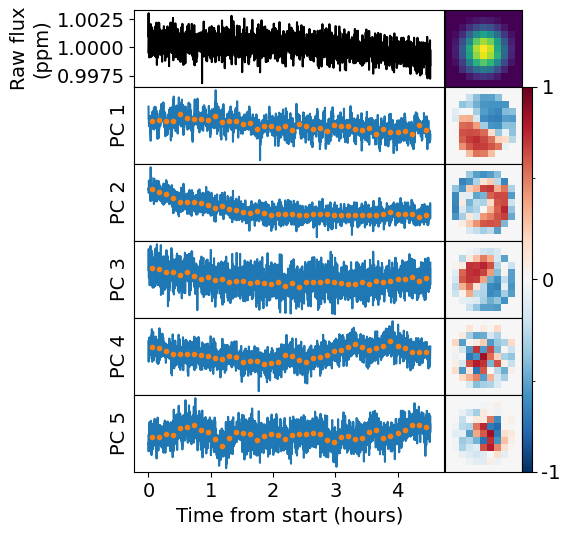

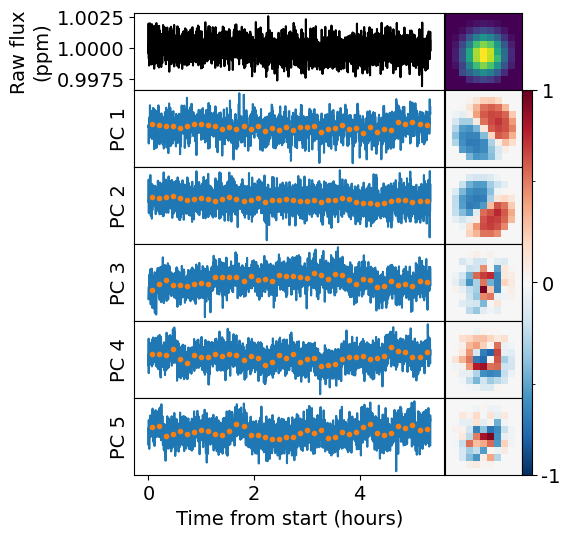

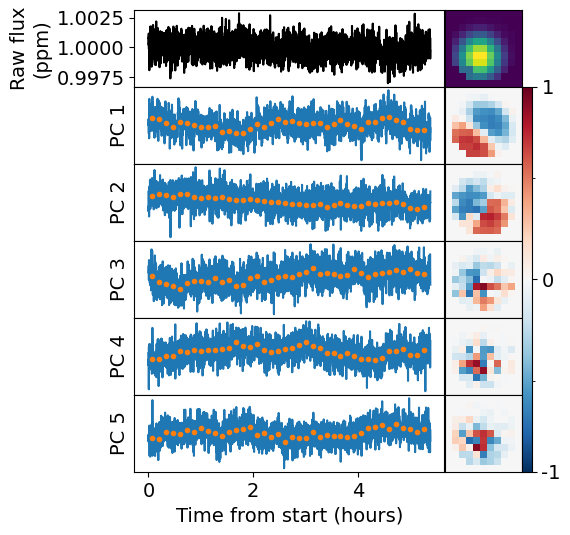

In [42]:
for i, fit in enumerate(visit_fits[:-1]):
	f = fit.raw_flux
	t = fit.time
	frame = fit.frames[0]
	ev, evec, _ = perform_fn_pca_on_aperture(fit.frames)
	plot(t, f, frame, ev, evec, f"PCA_trimmed_lightcurve_{i}.png")

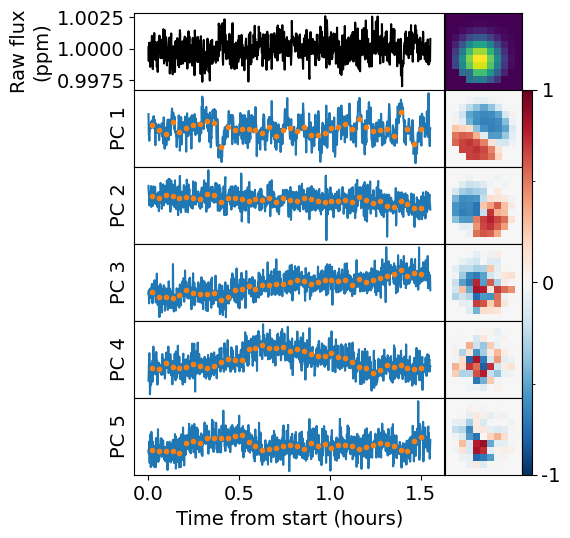

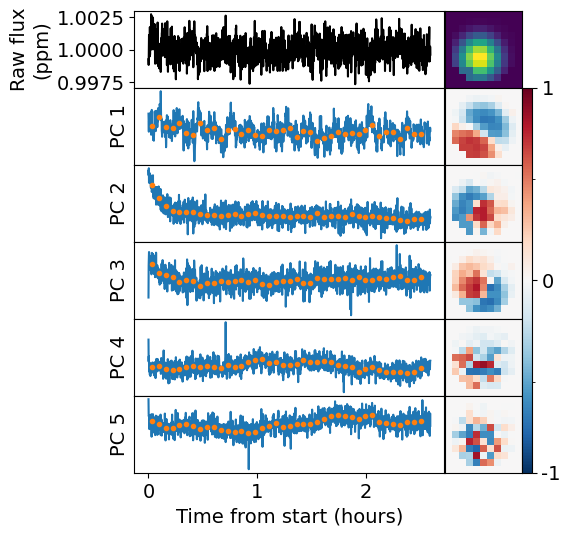

In [43]:
visit4 = visit_fits[-1]

cutoff = np.where(np.diff(visit4.time) > 0.01)[0][0] + 1

f = visit4.raw_flux[:cutoff]
t = visit4.time[:cutoff]
frame = fit.frames[0]
ev, evec, _ = perform_fn_pca_on_aperture(visit4.frames[:cutoff])
plot(t, f, frame, ev, evec, f"PCA_trimmed_lightcurve_4a.png")

f = visit4.raw_flux[cutoff:]
t = visit4.time[cutoff:]
frame = fit.frames[cutoff]
ev, evec, _ = perform_fn_pca_on_aperture(visit4.frames[cutoff:])
plot(t, f, frame, ev, evec, f"PCA_trimmed_lightcurve_4b.png")